# 11 — Logistic Regression Classification
**Course:** 23CSE301 Machine Learning — Capstone Project  
**Review:** Review 1 — Classification Part A  
**Dataset:** `riceClassification_sampled.csv`

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42
TEST_SIZE = 0.20

def resolve_file(filename):
    candidates = [
        Path("../data") / filename,
        Path("data") / filename,
        Path("/mnt/data") / filename,
        Path(filename)
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find {filename}")

class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.q1_ = np.nanpercentile(X, 25, axis=0)
        self.q3_ = np.nanpercentile(X, 75, axis=0)
        iqr = self.q3_ - self.q1_
        self.lower_ = self.q1_ - self.factor * iqr
        self.upper_ = self.q3_ + self.factor * iqr
        return self
    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lower_, self.upper_)

In [2]:
DATA_PATH = resolve_file("riceClassification_sampled.csv")
TARGET = "Class"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.dtypes.to_frame("dtype"))
print("\nMissing values:")
display(df.isnull().sum().to_frame("missing"))
print("\nDuplicate rows:", df.duplicated().sum())
print("\nClass distribution:")
display(df[TARGET].value_counts().sort_index())
display(df.head())

Shape: (1900, 12)


,dtype
id,int64
Area,int64
MajorAxisLength,float64
MinorAxisLength,float64
Eccentricity,float64
ConvexArea,int64
EquivDiameter,float64
Extent,float64
Perimeter,float64
Roundness,float64



Missing values:


,missing
id,0
Area,0
MajorAxisLength,0
MinorAxisLength,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Perimeter,0
Roundness,0



Duplicate rows: 0

Class distribution:


Class
0     863
1    1037
Name: count, dtype: int64

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,18057,9429,174.671378,69.661360,0.917032,9752,109.569045,0.644938,406.975,0.715385,2.507436,0
1,3257,5842,145.807572,51.673280,0.935096,6020,86.245379,0.641978,330.790,0.670914,2.821721,1
2,17107,8359,158.012446,67.848264,0.903121,8540,103.164962,0.666268,370.413,0.765582,2.328909,0
3,9811,6493,167.571643,50.974529,0.952610,6737,90.923838,0.796687,366.921,0.606052,3.287360,1
4,9564,5594,153.172203,47.071526,0.951609,5770,84.394917,0.496847,337.176,0.618328,3.254031,1


### A1 observation — write a dataset-specific observation using the actual audit output.

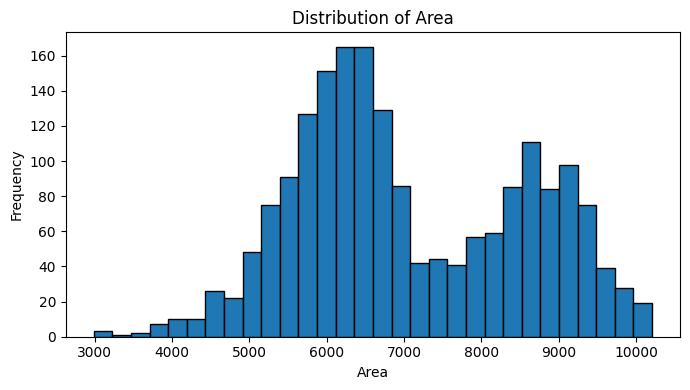

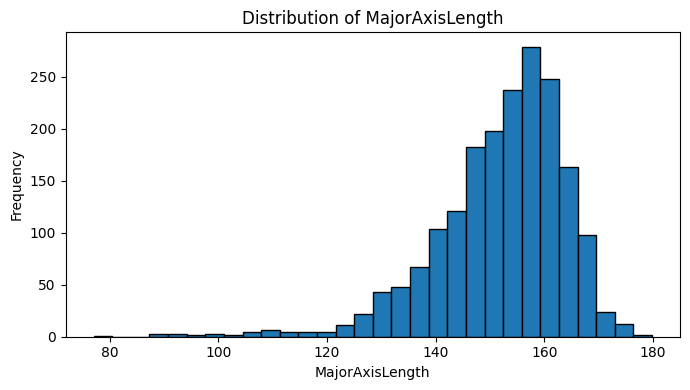

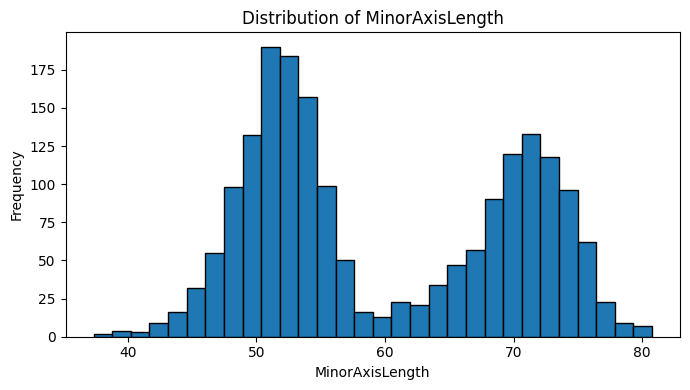

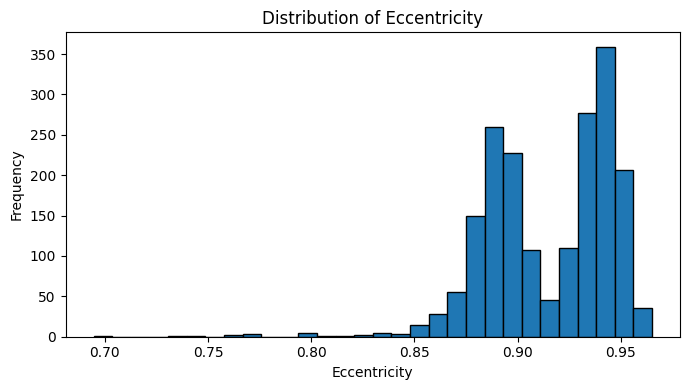

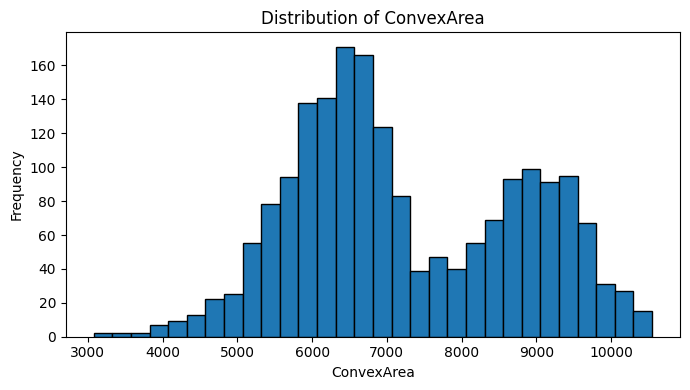

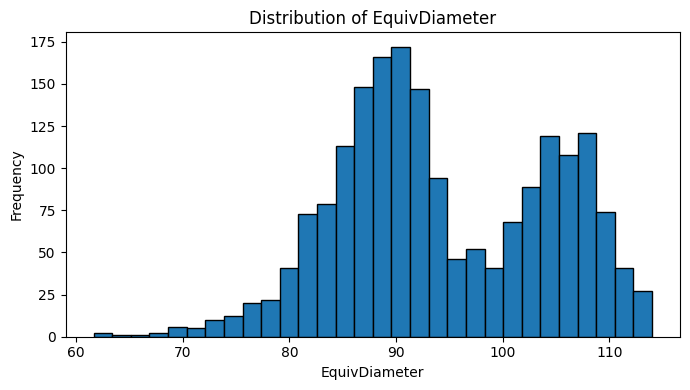

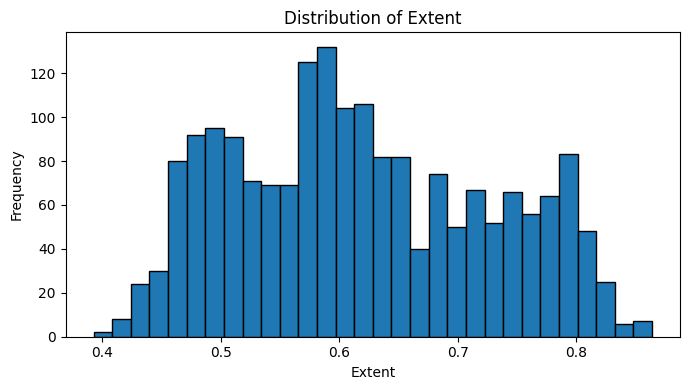

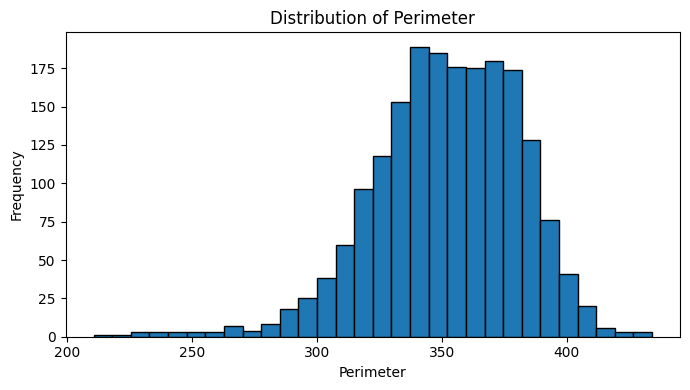

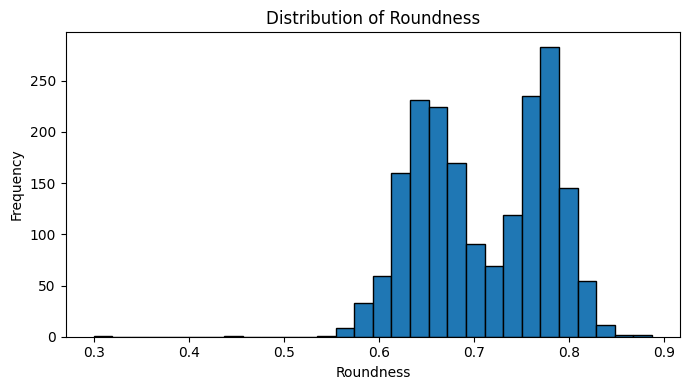

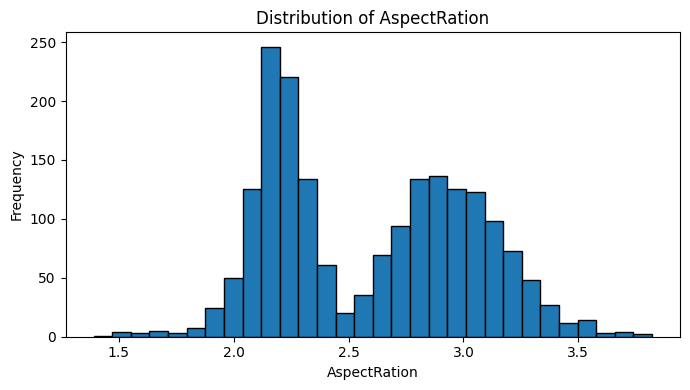

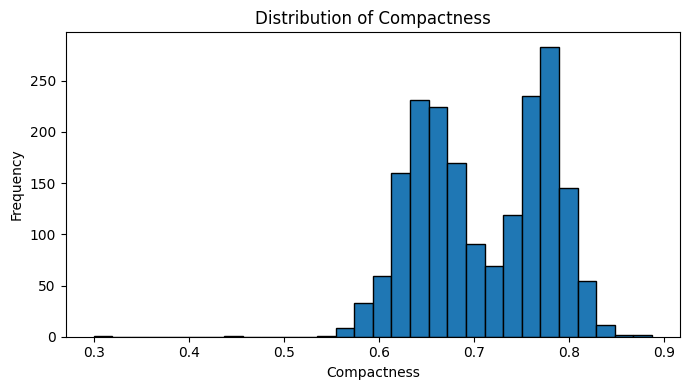

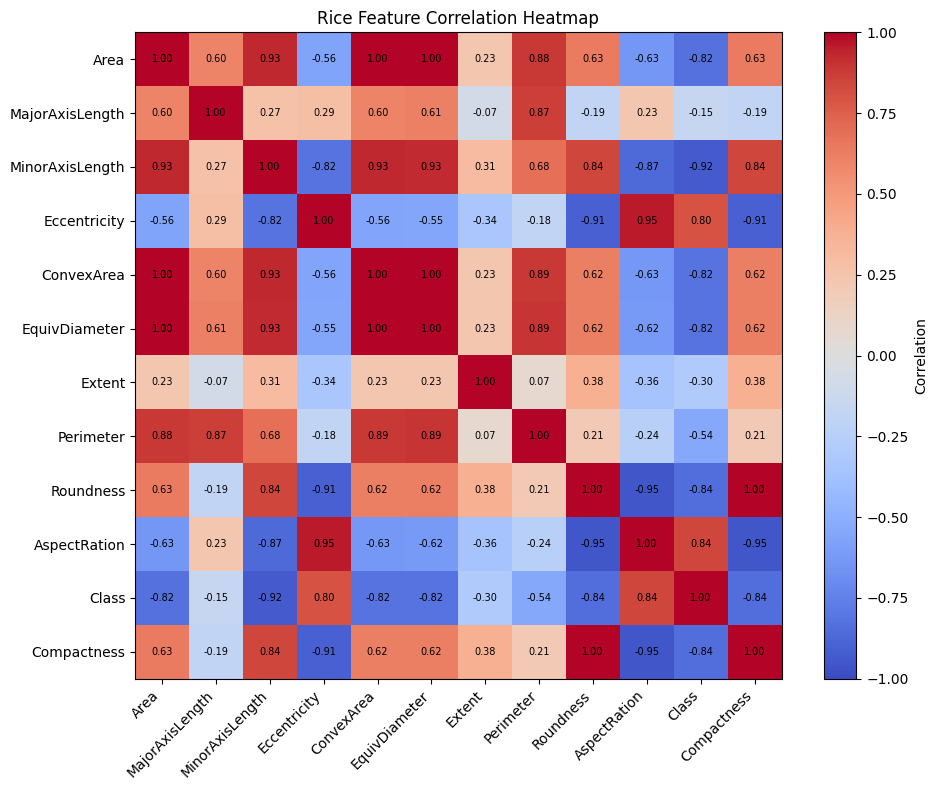

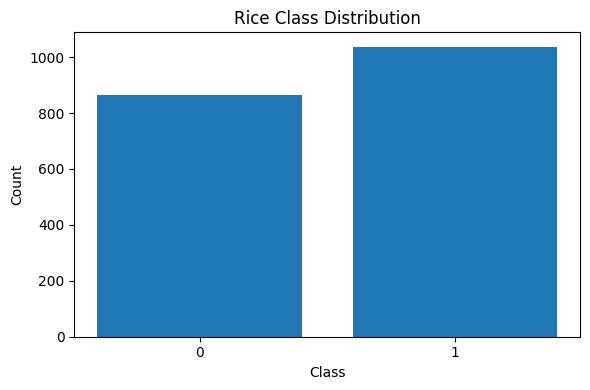

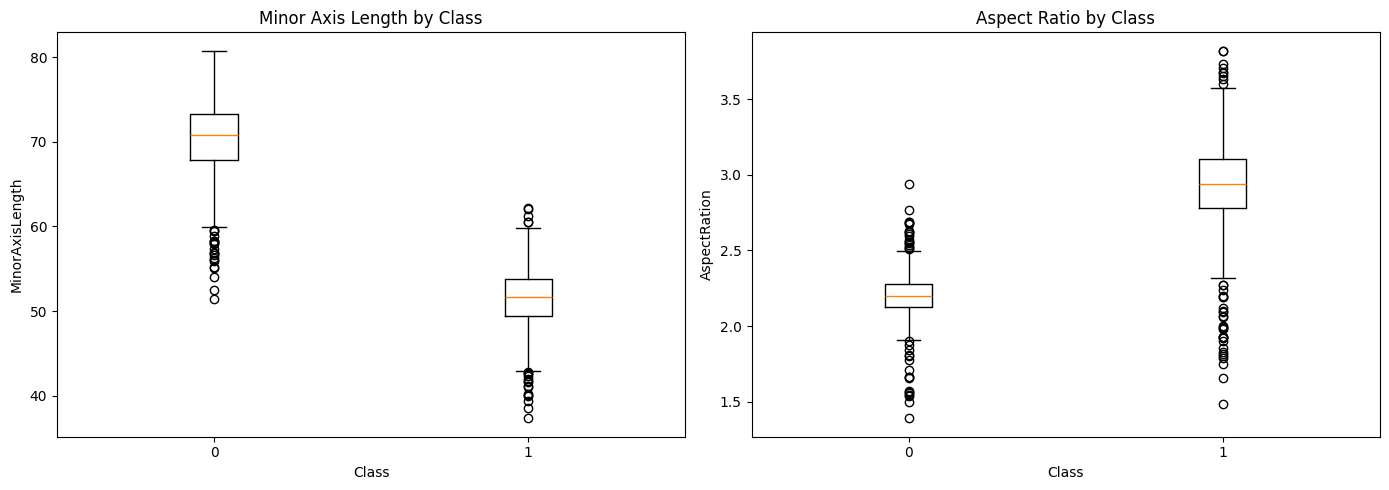

In [3]:
df = df.copy()
df = df.drop(columns=["id"], errors="ignore")
df["Compactness"] = 4 * np.pi * df["Area"] / (df["Perimeter"]**2 + 1e-8)

numeric_cols = [c for c in df.select_dtypes(include=np.number).columns if c != TARGET]

for col in numeric_cols:
    plt.figure(figsize=(7,4))
    plt.hist(df[col].dropna(), bins=30, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

corr = df.select_dtypes(include=np.number).corr()
fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Rice Feature Correlation Heatmap")
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
plt.tight_layout()
plt.show()

counts = df[TARGET].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Rice Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1,2, figsize=(14,5))
for cls in sorted(df[TARGET].unique()):
    axes[0].boxplot(df.loc[df[TARGET]==cls, "MinorAxisLength"], positions=[cls])
    axes[1].boxplot(df.loc[df[TARGET]==cls, "AspectRation"], positions=[cls])
axes[0].set_title("Minor Axis Length by Class")
axes[0].set_xlabel("Class"); axes[0].set_ylabel("MinorAxisLength")
axes[1].set_title("Aspect Ratio by Class")
axes[1].set_xlabel("Class"); axes[1].set_ylabel("AspectRation")
plt.tight_layout()
plt.show()

### A3 observation — write observations for distributions, heatmap, class balance and feature-vs-class plots.

## 2. Cleaning & feature engineering

In [4]:
print("Duplicate rows before:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

outliers = []
for col in [c for c in df.select_dtypes(include=np.number).columns if c != TARGET]:
    q1, q3 = df[col].quantile([0.25,0.75])
    iqr = q3-q1
    lower, upper = q1-1.5*iqr, q3+1.5*iqr
    outliers.append([col, int(((df[col]<lower)|(df[col]>upper)).sum())])

display(pd.DataFrame(outliers, columns=["Feature","IQR Outliers"]))
print("Missing values:")
display(df.isnull().sum().to_frame("missing"))
display(df[["Area","Perimeter","Compactness","Class"]].head())

Duplicate rows before: 0


,Feature,IQR Outliers
0,Area,0
1,MajorAxisLength,51
2,MinorAxisLength,0
3,Eccentricity,13
4,ConvexArea,0
5,EquivDiameter,1
6,Extent,0
7,Perimeter,31
8,Roundness,2
9,AspectRation,0


Missing values:


,missing
Area,0
MajorAxisLength,0
MinorAxisLength,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Perimeter,0
Roundness,0
AspectRation,0


,Area,Perimeter,Compactness,Class
0,9429,406.975,0.715385,0
1,5842,330.790,0.670914,1
2,8359,370.413,0.765582,0
3,6493,366.921,0.606052,1
4,5594,337.176,0.618328,1


### B1 justification — explain duplicate, missing-value and outlier handling, and why the record ID is excluded.

### B3 justification — explain why compactness is a meaningful geometric feature for classifying rice grains.

In [5]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("iqr", IQRClipper()),
        ("scaler", StandardScaler())
    ]), numeric_features)
])

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class proportions:")
print(y_train.value_counts(normalize=True).sort_index())
print("Test class proportions:")
print(y_test.value_counts(normalize=True).sort_index())

Train shape: (1520, 11)
Test shape: (380, 11)
Train class proportions:
Class
0    0.453947
1    0.546053
Name: proportion, dtype: float64
Test class proportions:
Class
0    0.455263
1    0.544737
Name: proportion, dtype: float64


### B2 note
The split is stratified and all imputation, clipping and scaling occur inside the pipeline to prevent leakage.

## 3. Logistic Regression Classification
Logistic Regression is the baseline linear classifier; transformed-feature coefficients relate to log-odds.

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)
proba = pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred, average="weighted", zero_division=0)
recall = recall_score(y_test, pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, pred, average="weighted", zero_division=0)
auc = roc_auc_score(y_test, proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1: {f1:.4f}")
print(f"ROC-AUC: {auc:.4f}")

Accuracy: 0.9816
Weighted Precision: 0.9819
Weighted Recall: 0.9816
Weighted F1: 0.9816
ROC-AUC: 0.9960


## 4. Confusion matrix — D2

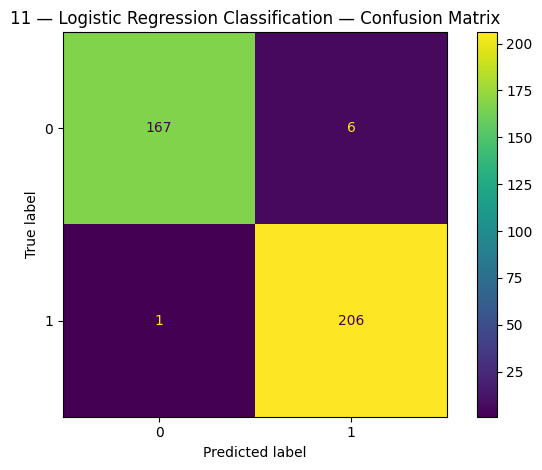

Confusion matrix:
 [[167   6]
 [  1 206]]


In [7]:
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("11 — Logistic Regression Classification — Confusion Matrix")
plt.tight_layout()
plt.show()
print("Confusion matrix:\n", cm)

### D2 observation — identify the class confusions and connect them to the accuracy/F1 values using the actual result.

## 5. 5-fold cross-validation

In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring="accuracy")
print("CV accuracy scores:", np.round(cv_scores,4))
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Std CV accuracy: {cv_scores.std():.4f}")

CV accuracy scores: [0.9921 0.9921 0.9816 0.9947 0.9842]
Mean CV accuracy: 0.9889
Std CV accuracy: 0.0051


### CV observation — compare the mean CV accuracy with held-out test accuracy.

## 6. Save result for collective Part-A comparison

In [9]:
root = Path("..") if Path("../data").exists() else Path(".")
(root/"results").mkdir(parents=True, exist_ok=True)
(root/"models").mkdir(parents=True, exist_ok=True)

joblib.dump(
    pipeline,
    root/"models"/"logistic_regression_classification_baseline.joblib"
)

pd.DataFrame([{
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1_weighted": f1,
    "ROC_AUC": auc,
    "CV_Accuracy_Mean": cv_scores.mean(),
    "CV_Accuracy_Std": cv_scores.std()
}]).to_csv(
    root/"results"/"classification_logistic_results.csv",
    index=False
)

print("Saved model and result CSV.")

Saved model and result CSV.
